<a href="https://colab.research.google.com/github/Kfafa2024/AIML-1030/blob/Assignments/%5BNotebook%5D_Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import required modules

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  #remeber this from last week?
import warnings
warnings.filterwarnings("ignore")

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load MNIST Data

In [19]:
# MNIST dataset downloaded from Kaggle :
#https://www.kaggle.com/c/digit-recognizer/data

# Functions to read and show images.

d0 = pd.read_csv('/content/drive/MyDrive/AIML 1030/Week 3/mnist_train.csv')

#Preparing the data below in order to call it later

print(d0.head(5)) # print first five rows of d0.

# save the labels into a variable l.
l = d0['label']

# Drop the label feature and store the pixel data in d.
d = d0.drop("label",axis=1)

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [20]:
print(d.shape)
#Prints out how many instances of how many variables below
# d shape has 42000 instances of 784 sets of pixels
print(l.shape)
#Prints the value of the variable l for labels
#it is a vector/one column matrix with 42000 labels

(42000, 784)
(42000,)


In [21]:
#printing d and it will dsiplay the 42000 instances of pixels below
print(d)

       pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0           0       0       0       0       0       0       0       0       0   
1           0       0       0       0       0       0       0       0       0   
2           0       0       0       0       0       0       0       0       0   
3           0       0       0       0       0       0       0       0       0   
4           0       0       0       0       0       0       0       0       0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995       0       0       0       0       0       0       0       0       0   
41996       0       0       0       0       0       0       0       0       0   
41997       0       0       0       0       0       0       0       0       0   
41998       0       0       0       0       0       0       0       0       0   
41999       0       0       0       0       0       0       0       0       0   

       pixel9  ...  pixel77

In [22]:
#Printing l and it will display the one columned matrix
#with 42000 labeles
print(l)

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64


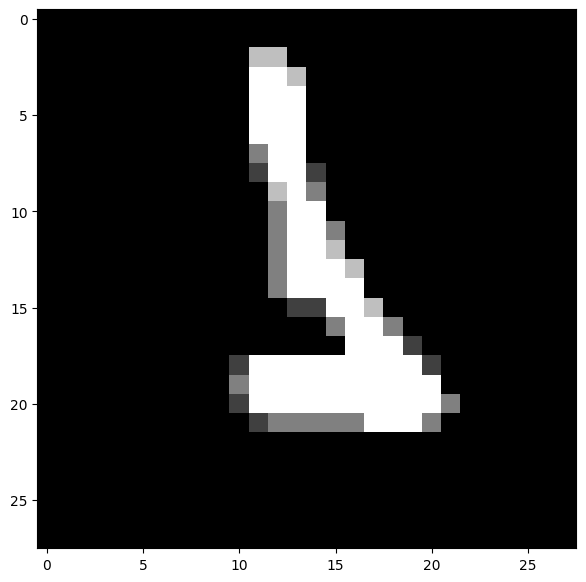

1


In [23]:
# display or plot a number.
plt.figure(figsize=(7,7))
#The (7,7) is the 1 dimensional size
#plt calls matplotlib to do graphics and setting up a canvas for an image
#by using figure and creating a size
idx = 60
#idx is a variable for index and it is selecting row 60 of 42,000

grid_data = d.iloc[idx].to_numpy().reshape(28,28)  # reshape from 1d to 2d pixel array
#this is pulling the selected row from  idx, converting it to numpy, and reshaping it to
#28 by 28 pixels
#The .iloc is a powerful, integer-location based indexing method in Pandas DataFrames. It is primarily used for selection by position.
plt.imshow(grid_data, interpolation = "none", cmap = "gray")
#The shades of gray go from 0 to 255 you can run this code cell separately to see the numerical
#representations of gray, and and this determines how black and white the image will print
plt.show()  #check this out!

#display the selected index variable from the label matrix
#(l) is your one columned matrix you assigned earlier
print(l[idx])

#  2D Visualization using PCA

In [24]:
# Data-preprocessing: Standardizing the data

from sklearn.preprocessing import StandardScaler
standardized_data = StandardScaler().fit_transform(data)
print(standardized_data.shape)


(42000, 784)


In [25]:
#pick the first 15k data points to work on for time efficiency
#exercise: perform the same analysis on all 42k data-points

labels_2 = l.head(15000  )
# I pulled the first 15000 rows from the labels matrix assigned to the l variable

data_2=d.head(15000)

print("the shape of sample data = ", data.shape)

the shape of sample data =  (42000, 784)


In [26]:
#Here I am doing the assigned exercise requested in the above cell
#To pull ALL the rows of the labels matrix I drop the head and simply
#Call the selected matrix
labels = l
#I drop the head specification in data as well to tell the program I want all
data=d

#I ask for Python to print the string below and to describe the amount of
#data points & dimensions contained in the labels matrix


print("the shape of sample data = ", data.shape)

the shape of sample data =  (42000, 784)


In [27]:
#find the co-variance matrix which is : A^T * A
sample_data = standardized_data

# matrix multiplication using numpy
covar_matrix = np.matmul(sample_data.T , sample_data)

print ( "The shape of variance matrix = ", covar_matrix.shape)
#This matrix represents the covariance between all pairs of
#dimensions in the data. In this case, since the sample_data has 784 features (pixels) 28 height, by 28 width
#the covariance matrix has a shape of (784, 784).


The shape of variance matrix =  (784, 784)


### Note on `scipy.linalg.eigh` parameter change:

If you encounter a `TypeError: eigh() got an unexpected keyword argument 'eigvals'` when running the PCA code, it's likely due to a version difference in the SciPy library.

*   **Older SciPy versions** used the `eigvals` parameter to specify the range of eigenvalues to return (e.g., `eigvals=(low_idx, high_idx)`).
*   **Newer SciPy versions** have replaced or deprecated `eigvals` in favor of `subset_by_index`. This parameter allows you to specify the exact indices of the eigenvalues you want. Since `eigh` returns eigenvalues in ascending order, to get the two largest eigenvalues from a 784x784 covariance matrix, you would use `subset_by_index=[782, 783]` (for 0-indexed values).

The corrected code uses `subset_by_index=[782, 783]` to ensure compatibility with modern SciPy implementations.

In [28]:
# finding the top two eigen-values and corresponding eigen-vectors
# for projecting onto a 2-Dim space.

from scipy.linalg import eigh
#The set up for PCA (Principal Component Analysis)

# the parameter 'eigvals' is defined (low value to heigh value)
# eigh function will return the eigen values in asending order
# this code generates only the top 2 (782 and 783) eigenvalues.
# values, vectors = eigh(covar_matrix, eigvals=(782,783)) # Original line, caused TypeError
# Corrected line: 'subset_by_index' is the correct parameter in modern SciPy versions to select eigenvalues by their index.
# We are selecting indices 782 and 783 to get the two largest eigenvalues (0-indexed, with eigh returning sorted eigenvalues).
values, vectors = eigh(covar_matrix, subset_by_index=[782, 783])

#I took note of the above mentioned correction and what the parameter does

print("Shape of eigen vectors = ",vectors.shape)
# converting the eigen vectors into (2,d) shape for easyness of further computations
vectors = vectors.T

print("Updated shape of eigen vectors = ",vectors.shape)
# here the vectors[1] represent the eigen vector corresponding 1st principal eigen vector
# here the vectors[0] represent the eigen vector corresponding 2nd principal eigen vector

Shape of eigen vectors =  (784, 2)
Updated shape of eigen vectors =  (2, 784)


In [29]:
# projecting the original data sample on the plane
#formed by two principal eigen vectors by vector-vector multiplication.

import matplotlib.pyplot as plt
new_coordinates = np.matmul(vectors, sample_data.T)

print (" resultant new data points' shape ", vectors.shape, "X", sample_data.T.shape," = ", new_coordinates.shape)

 resultant new data points' shape  (2, 784) X (784, 42000)  =  (2, 42000)


In [30]:
import pandas as pd

# appending label to the 2d projected data
new_coordinates = np.vstack((new_coordinates, labels)).T

# creating a new data frame for ploting the labeled points.
dataframe = pd.DataFrame(data=new_coordinates, columns=("1st_principal", "2nd_principal", "label"))
print(dataframe.head())

   1st_principal  2nd_principal  label
0      -5.226445      -5.140478    1.0
1       6.032996      19.292332    0.0
2      -1.705813      -7.644503    1.0
3       5.836139      -0.474207    4.0
4       6.024818      26.559574    0.0


In [31]:
import pandas as pd
df=pd.DataFrame()
df['1st']=[-5.558661,-5.043558,6.193635 ,19.305278]
df['2nd']=[-1.558661,-2.043558,2.193635 ,9.305278]
df['label']=[1,2,3,4]

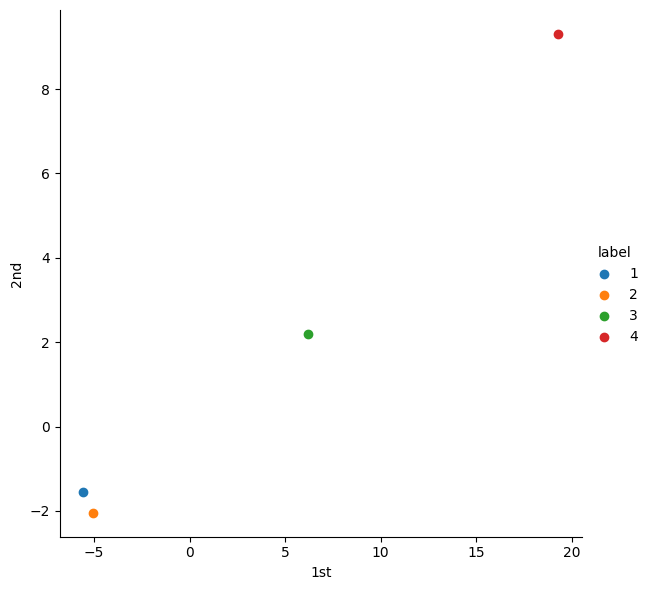

In [32]:
import seaborn as sn
import matplotlib.pyplot as plt
sn.FacetGrid(df, hue="label", height=6).map(plt.scatter, '1st', '2nd').add_legend()
plt.show()

<Axes: xlabel='1st', ylabel='2nd'>

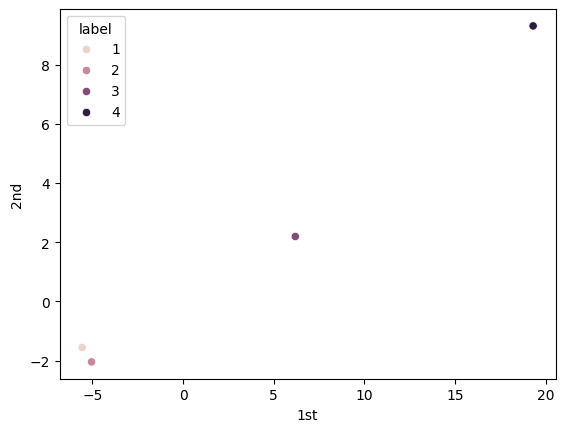

In [33]:
sn.scatterplot(x="1st",y="2nd",hue="label",data=df)

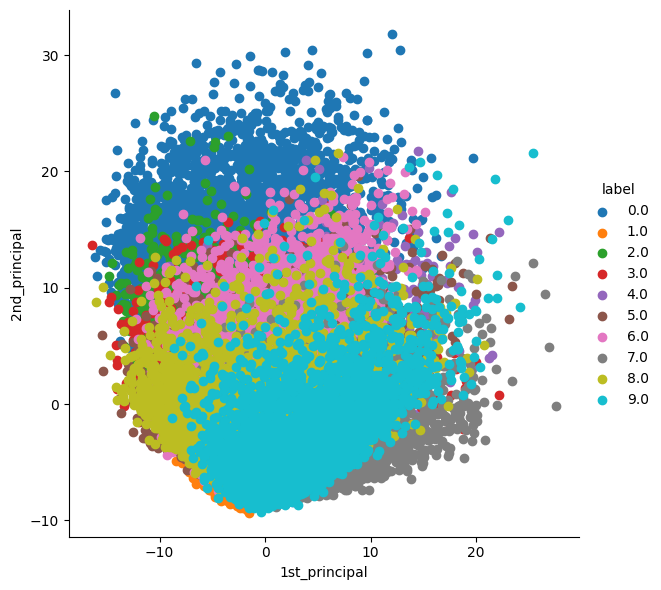

In [34]:
# ploting the 2d data points with seaborn
import seaborn as sn
#Seaborn is a powerful Python data visualization library based on Matplotlib.
# It provides a high-level interface for drawing attractive and informative
# statistical graphics. It simplifies the creation of many common types of plots,
# making it easier to explore and understand data. In this notebook, we've used Seaborn for:
#FacetGrid: This allows you to visualize the distribution of a variable or the relationship between
#multiple variables across different subsets of a dataset. It's particularly useful for comparing various
#groups within your data, as seen when plotting the principal components by their labels.
#scatterplot: This function creates a scatter plot, which is excellent for showing the relationship between two numerical variables. We've used it to visualize the 2D projected data points.
sn.FacetGrid(dataframe, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

### Note on `seaborn.FacetGrid` parameter change:

If you encounter a `TypeError: FacetGrid.__init__() got an unexpected keyword argument 'size'` when running Seaborn plotting code, it's because the `size` parameter has been deprecated in newer versions of Seaborn.

*   **Older Seaborn versions** used the `size` parameter to control the height of each facet in the grid.
*   **Newer Seaborn versions** have replaced `size` with `height`. The `height` parameter now directly specifies the height of each facet in inches. You can use the `aspect` parameter to control the width-to-height ratio if needed.

To diagnose this, you can look at the traceback for the `TypeError` and identify the parameter causing the issue. To fix it, simply replace `size=` with `height=` in your `FacetGrid` calls.

<Axes: xlabel='1st_principal', ylabel='2nd_principal'>

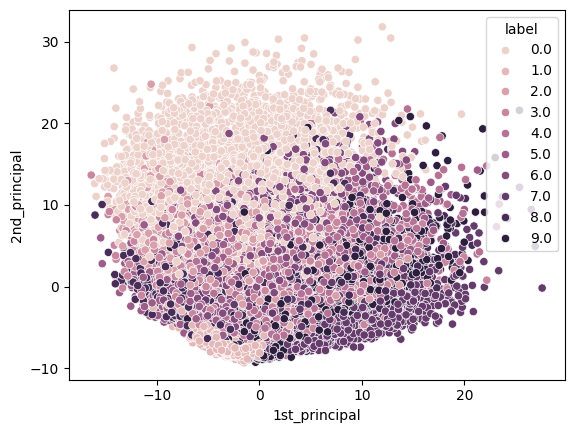

In [35]:
sn.scatterplot(x="1st_principal",y="2nd_principal",legend="full",hue="label",data=dataframe)

# PCA using Scikit-Learn

In [36]:
# initializing the pca
from sklearn import decomposition
pca = decomposition.PCA()


In [37]:
# configuring the parameteres
# the number of components = 2
pca.n_components = 2
pca_2d_components = pca.fit_transform(sample_data)

# pca_reduced will contain the 2-d projects of simple data
print("shape of pca_2d_components.shape = ", pca_2d_components.shape)

shape of pca_2d_components.shape =  (42000, 2)


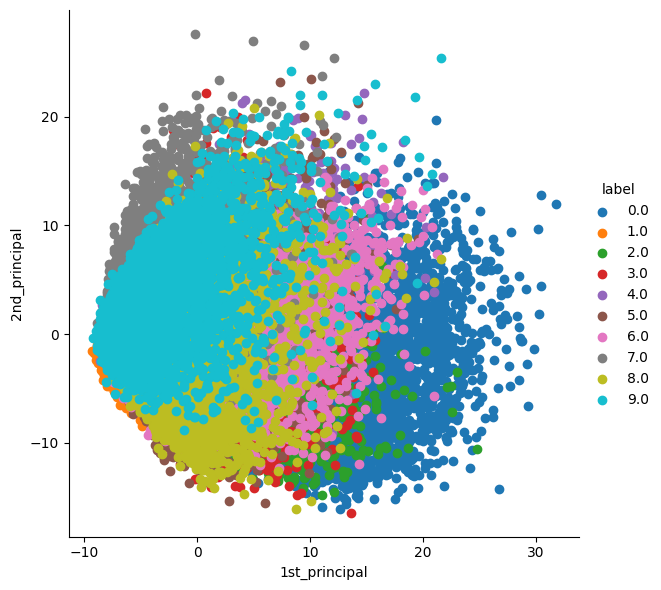

In [38]:
# attaching the label for each 2-d data point
pca_data_with_labels = np.vstack((pca_2d_components.T, labels)).T

# creating a new data fram which help us in ploting the result data
pca_df = pd.DataFrame(data=pca_data_with_labels, columns=("1st_principal", "2nd_principal", "label"))
sn.FacetGrid(pca_df, hue="label", height=6).map(plt.scatter, '1st_principal', '2nd_principal').add_legend()
plt.show()

### Note on `seaborn.FacetGrid` parameter change:

If you encounter a `TypeError: FacetGrid.__init__() got an unexpected keyword argument 'size'` when running Seaborn plotting code, it's because the `size` parameter has been deprecated in newer versions of Seaborn.

*   **Older Seaborn versions** used the `size` parameter to control the height of each facet in the grid.
*   **Newer Seaborn versions** have replaced `size` with `height`. The `height` parameter now directly specifies the height of each facet in inches. You can use the `aspect` parameter to control the width-to-height ratio if needed.

To diagnose this, you can look at the traceback for the `TypeError` and identify the parameter causing the issue. To fix it, simply replace `size=` with `height=` in your `FacetGrid` calls.

# PCA for dimensionality redcution (not for visualization)

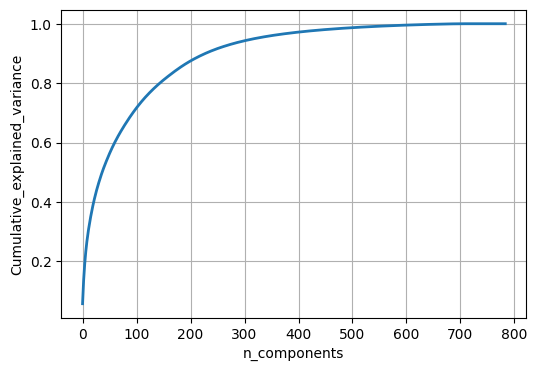

In [39]:
# PCA for dimensionality redcution (non-visualization)

pca.n_components = 784
pca_data = pca.fit_transform(sample_data)

percentage_var_explained = pca.explained_variance_ / np.sum(pca.explained_variance_);

cum_var_explained = np.cumsum(percentage_var_explained)

# Plot the PCA spectrum
plt.figure(1, figsize=(6, 4))

plt.clf()
plt.plot(cum_var_explained, linewidth=2)
plt.axis('tight')
plt.grid()
plt.xlabel('n_components')
plt.ylabel('Cumulative_explained_variance')
plt.show()


# If we take 200-dimensions, approx. 90% of variance is explained.

# t-SNE using Scikit-Learn

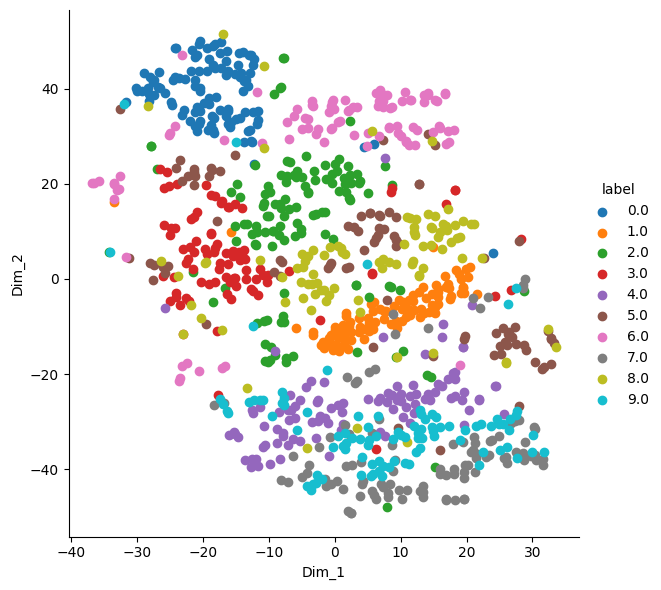

In [40]:
# TSNE

from sklearn.manifold import TSNE

# Picking the top 1000 points as TSNE takes a lot of time for 15K points
data_1000 = standardized_data[0:1000,:]
labels_1000 = labels[0:1000]

model = TSNE(n_components=2, random_state=0)
# configuring the parameteres
# the number of components = 2
# default perplexity = 30
# default learning rate = 200
# default Maximum number of iterations for the optimization = 1000

tsne_data = model.fit_transform(data_1000)


# creating a new data frame which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.show()

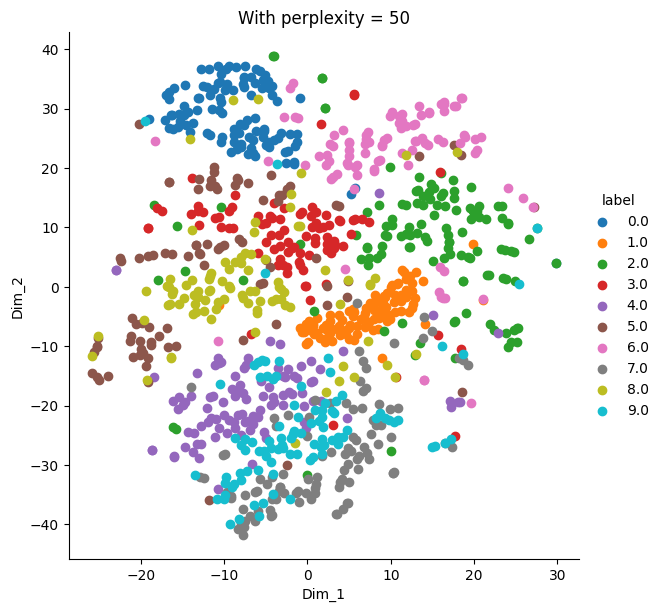

In [41]:
model = TSNE(n_components=2, random_state=0, perplexity=50)
tsne_data = model.fit_transform(data_1000)

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 50')
plt.show()

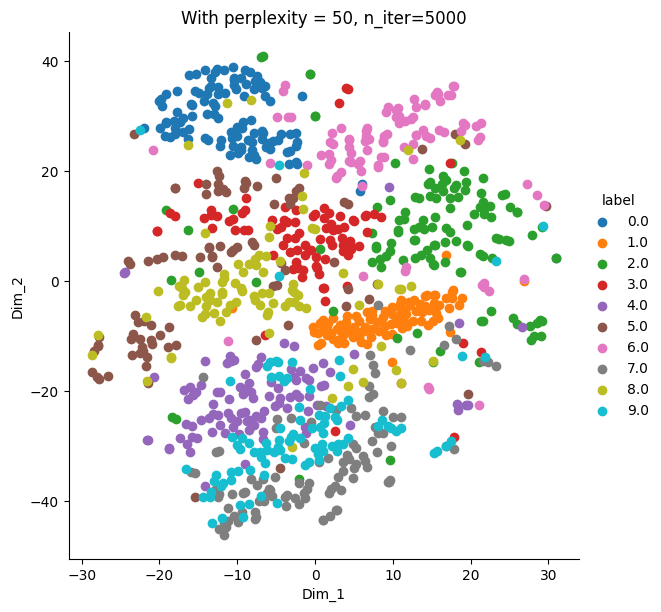

In [42]:
model = TSNE(n_components=2, random_state=0, perplexity=50,  n_iter=5000)
tsne_data = model.fit_transform(data_1000)

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 50, n_iter=5000')
plt.show()

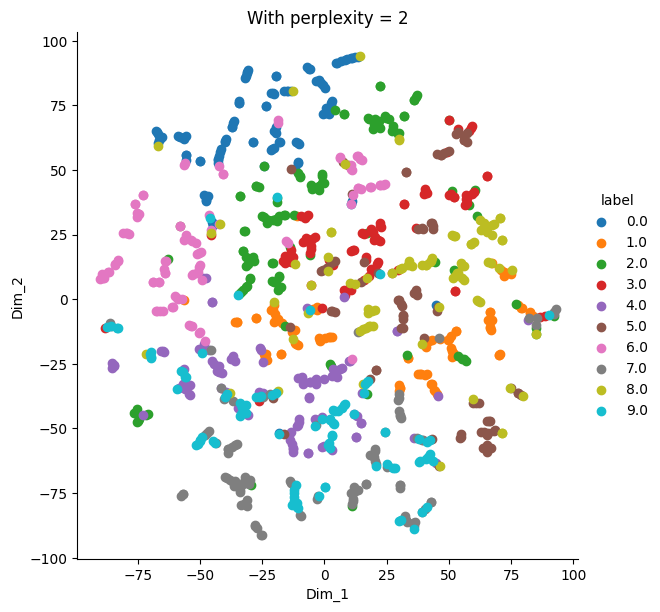

In [43]:
model = TSNE(n_components=2, random_state=0, perplexity=2)
tsne_data = model.fit_transform(data_1000)

# creating a new data fram which help us in ploting the result data
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data=tsne_data, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 2')
plt.show()

In [44]:
#Excercise: Run the same analysis using 42K points with various
#values of perplexity and iterations.

# If you use all of the points, you can expect plots like this blog below:
# http://colah.github.io/posts/2014-10-Visualizing-MNIST/

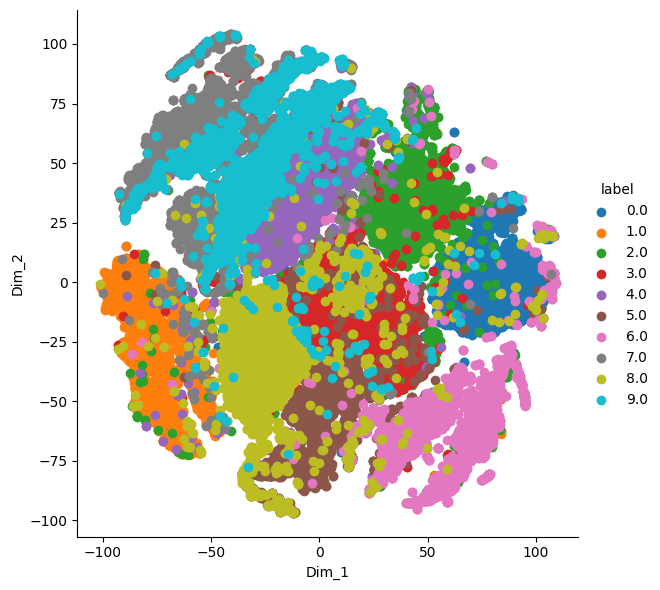

In [45]:
#The requested Assignment
# TSNE

from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

# making variables for the 42k points
data_42000 = standardized_data # Use the already defined standardized_data
labels_42000 = labels # Use the already defined labels

model_42000 = TSNE(n_components=2, random_state=0)
# configuring the parameteres
# the number of components = 2
# default perplexity = 30
# default learning rate = 200
# default Maximum number of iterations for the optimization = 1000

tsne_data_42000 = model_42000.fit_transform(data_42000)


# creating a new data frame which help us in ploting the result data
tsne_data_42000_with_labels = np.vstack((tsne_data_42000.T, labels_42000)).T
tsne_df_42000 = pd.DataFrame(data=tsne_data_42000_with_labels, columns=("Dim_1", "Dim_2", "label"))

# Ploting the result of tsne
sn.FacetGrid(tsne_df_42000, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

# Ensure data_42000 and labels_42000 are defined
data_42000 = standardized_data
labels_42000 = labels

#I changed the perplexity and iterations
model_42000 = TSNE(n_components=2, random_state=3, perplexity=3000,  n_iter=650)
tsne_data_42000 = model_42000.fit_transform(data_42000)

# creating a new data fram which help us in ploting the result data

tsne_data_42000_with_labels = np.vstack((tsne_data_42000.T, labels_42000)).T
tsne_df_42000 = pd.DataFrame(data=tsne_data_42000_with_labels, columns=("Dim_1", "Dim_2", "label"))


# Ploting the result of tsne

sn.FacetGrid(tsne_df_42000, hue="label", height=6).map(plt.scatter, 'Dim_1', 'Dim_2').add_legend()
plt.title('With perplexity = 3000 n_iter = 650')
plt.show()


In [2]:
#Trying to duplicate the interacvtive MNIST cube from the linked blog
#I have to import a few more things
import tensorflow as tf
import ipywidgets as widgets
from ipywidgets import interact

In [ ]:
#Training the visualization model and making it 3d
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
# x_train is already (60000, 28, 28) - acts as a stack of images


In [ ]:
def plot_digit(index):
    plt.imshow(x_train[index], cmap='gray')
    plt.title(f'Label: {y_train[index]}')
    plt.axis('off')
    plt.show()

#The slider goes through every pixel but does not resemble the widget I tried to duplicate

interact(plot_digit, index=widgets.IntSlider(min=0, max=59999, step=1, value=0));


In [ ]:
#This is my second attempt with the help of google
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist # Or use another method to load MNIST

# Load the MNIST data (example using Keras dataset loader)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten the images (28*28 = 784 pixels) and select a smaller subset for visualization
# Working with a large number of points (e.g., 1000) for a smoother interactive experience
num_samples = 1000
X_subset = X_train[:num_samples].reshape(num_samples, -1)
y_subset = y_train[:num_samples]

# Standardize the data
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X_subset)

# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
principal_components = pca.fit_transform(X_standardized)

# Create a DataFrame for easier handling with Plotly
df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2', 'PC3'])
df['label'] = y_subset.astype(str)
# Convert labels to string for hover text
df['hover_text'] = [f"Digit: {label}" for label in df['label']] # Customize the hover text


In [ ]:
#I still did not get the interactive graph I wanted but I really like this one
#I realized when looking at the page sourxe that everything is written in HTML/Javascript
#And that my former Computer Science Instrusctor is probably yelling at my git hub for this not being submitted via html as a web page

#Notes from google for future reference
#Key Features and Libraries
#Dimensionality Reduction: PCA is used to compress the 784-pixel data into the three most significant components (PC1, PC2, PC3) that explain the most variance.
#Plotly: This library renders interactive 3D plots directly in a Jupyter Notebook, Google Colab, or a web browser. You can rotate, zoom, and pan the "cube" to explore the data.
#Hover Functionality: Plotly's hover_name and hovertemplate parameters allow you to define custom information that appears when you hover your mouse over a data point (dot).
#This code will generate a 3D scatter plot in your environment, grouping the different digits into visible clusters that you can explore interactive

import plotly.express as px

# Create the 3D scatter plot
fig = px.scatter_3d(df,
                    x='PC1',
                    y='PC2',
                    z='PC3',
                    color='label',        # Color points by the digit label
                    hover_name='hover_text', # Text to display on hover
                    opacity=0.7,
                    title='MNIST Data Visualization with 3D PCA'
                   )

# Customize the hover data to include all relevant info
fig.update_traces(hovertemplate='<b>%{hover_name}</b><br>PC1: %{x}<br>PC2: %{y}<br>PC3: %{z}<br>')

# Display the plot
fig.show()

